# Cadena de Racha de Éxitos

**Modelo de Luis Rincón (2012), §3.2, pp. 33–34**

Sea $\{\xi_1, \xi_2, \ldots\}$ una sucesión de ensayos de Bernoulli independientes con probabilidad de éxito $p$ y de fracaso $q = 1-p$. Se define $X_n$ como el número de éxitos consecutivos previos al tiempo $n$, incluyendo el tiempo $n$.

El espacio de estados es $S = \{0, 1, 2, \ldots\}$ y las probabilidades de transición son:

$$p_{ij} = \begin{cases} p & \text{si } j = i+1 \\ q & \text{si } j = 0 \\ 0 & \text{otro caso} \end{cases}$$

In [1]:
import tkinter as tk
from tkinter import ttk
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np
from math import gcd

In [2]:
# Parámetros iniciales para la simulación
p = 0.7    # Probabilidad de éxito 
q = 1 - p  # Probabilidad de fracaso 
N = 5      # Longitud de la racha a conseguir
racha_inicial = 0

### 1. Matrices de Transición

#### A) Matriz de Transición Original (Recurrente Continua)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
q & p & 0 & 0 & \cdots & 0 & 0 
\end{pmatrix}$$

#### B) Matriz de Transición Modificada (Absorbente)

$$P = \begin{pmatrix}
q & p & 0 & 0 & \cdots & 0 & 0 \\
q & 0 & p & 0 & \cdots & 0 & 0 \\
q & 0 & 0 & p & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
q & 0 & 0 & 0 & \cdots & 0 & p \\
0 & 0 & 0 & 0 & \cdots & 0 & 1 
\end{pmatrix}$$

In [3]:
def construir_matriz_transicion(p: float, N: int) -> np.ndarray:
    q = 1 - p
    P = np.zeros((N + 1, N + 1))

    # Transiciones para los estados del 0 al N-1
    for estado_actual in range(N):
        P[estado_actual, estado_actual + 1] = p      # éxito
        P[estado_actual, 0]                 = q      # fracaso

    P[N, 1] = p      # éxito 
    P[N, 0] = q      # fracaso 
    
    return P

# Cálculo de matrices usando los parámetros iniciales
matriz_P = construir_matriz_transicion(p, N)

# Matriz absorbente 
matriz_P_absorbente = matriz_P.copy()
matriz_P_absorbente[N, :] = 0.0  
matriz_P_absorbente[N, N] = 1.0   # 1 en la diagonal para hacer el estado N absorbente

def imprimir_matriz(matriz):

    # Estados destino
    print(" " * 15, end="")
    for destino in range(matriz.shape[1]):
        print(f"   {destino:^5}   ", end="")
    print("\n" + "-" * (15 + 8 * matriz.shape[1]))

    # Filas de la matriz
    for origen in range(matriz.shape[0]):
        print(f"      Estado {origen}     |", end="")
        for destino in range(matriz.shape[1]):
            valor = matriz[origen, destino]
            print(f"   {valor:5.2f}  ", end="")
        print()
    print("\n")

# Imprimir ambas versiones inicialmente
imprimir_matriz(matriz_P)
imprimir_matriz(matriz_P_absorbente)

                    0          1          2          3          4          5     
---------------------------------------------------------------
      Estado 0     |    0.30      0.70      0.00      0.00      0.00      0.00  
      Estado 1     |    0.30      0.00      0.70      0.00      0.00      0.00  
      Estado 2     |    0.30      0.00      0.00      0.70      0.00      0.00  
      Estado 3     |    0.30      0.00      0.00      0.00      0.70      0.00  
      Estado 4     |    0.30      0.00      0.00      0.00      0.00      0.70  
      Estado 5     |    0.30      0.70      0.00      0.00      0.00      0.00  


                    0          1          2          3          4          5     
---------------------------------------------------------------
      Estado 0     |    0.30      0.70      0.00      0.00      0.00      0.00  
      Estado 1     |    0.30      0.00      0.70      0.00      0.00      0.00  
      Estado 2     |    0.30      0.00      0.00      0.70

### 2. Simulación

['p', 'p', 'p', 'p', 'p', 'p', 'q', 'p', 'p', 'q', 'p', 'q', 'p', 'p', 'p', 'q', 'p', 'q', 'p', 'p', 'q', 'p', 'p']


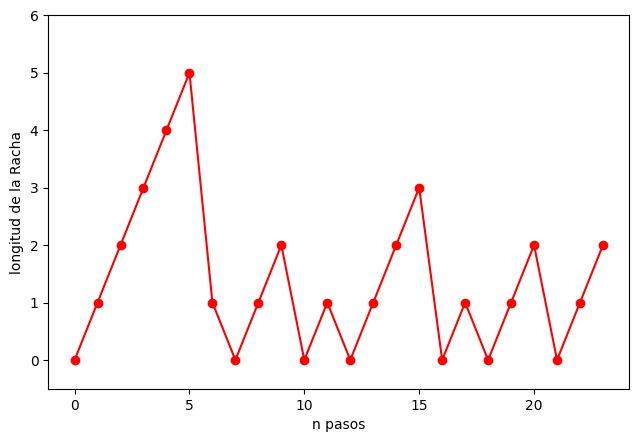

In [4]:
racha_actual = racha_inicial
historial_rachas = [racha_inicial]
historial_letras = [] 
corriendo = False

ultimo_modo_simulado = "Infinito" # Variable para controlar que tipo de simulación se ha ejecutado por última vez

def simular_paso():
    global racha_actual, corriendo, ultimo_modo_simulado
    
    if not corriendo:
        return  

    modo_elegido = combo_modo.get()
    ultimo_modo_simulado = modo_elegido

    # Ensayo de Bernoulli
    val = random.random()
    if val < p:
        historial_letras.append('p') 
        
        if modo_elegido == "Infinito":
            if racha_actual == N:
                racha_actual = 1  
            else:
                racha_actual += 1
                
        elif modo_elegido == "Absorbente":
            racha_actual += 1  
            
    else:
        historial_letras.append('q') 
        racha_actual = 0  

    # Guardar historial para la gráfica
    historial_rachas.append(racha_actual)
    if len(historial_rachas) > 50:  
        historial_rachas.pop(0)

    # Actualizar la gráfica
    ax.clear()
    ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
    ax.set_ylabel("longitud de la Racha")
    ax.set_xlabel("n pasos") 
    ax.set_ylim(-0.5, max(max(historial_rachas) + 1, N))
    canvas.draw()

    # Parar en el caso finito absorbente al alcanzar la racha
    if modo_elegido == "Absorbente" and racha_actual == N:
        corriendo = False
        boton_iniciar.config(state="normal")
        boton_parar.config(state="disabled")
        combo_modo.config(state="readonly") 
        
        # Guardamos de forma global
        global modo_analisis, letras_analisis_definitivo
        modo_analisis = "Absorbente"
        letras_analisis_definitivo = historial_letras.copy()
        return

    ventana.after(500, simular_paso)

# Interfaz gráfica
def iniciar():
    global corriendo, racha_actual, historial_rachas, historial_letras
    if not corriendo:
        racha_actual = racha_inicial
        historial_rachas = [racha_inicial]
        historial_letras = []
        
        corriendo = True
        boton_iniciar.config(state="disabled")
        boton_parar.config(state="normal")
        combo_modo.config(state="disabled") 
        simular_paso()

def parar():
    global corriendo, modo_analisis, letras_analisis_definitivo
    corriendo = False
    boton_iniciar.config(state="normal")
    boton_parar.config(state="disabled")
    combo_modo.config(state="readonly") 
    
    modo_analisis = combo_modo.get()
    letras_analisis_definitivo = historial_letras.copy()
    print(historial_letras) 

ventana = tk.Tk()
ventana.title("Simulador de Rachas de Éxitos")
ventana.geometry("750x550")

frame_controles = ttk.Frame(ventana)
frame_controles.pack(pady=15)

# Menú desplegable 
combo_modo = ttk.Combobox(frame_controles, values=["Infinito", "Absorbente"], width=20)
combo_modo.current(0) 
combo_modo.config(state="readonly")
combo_modo.pack(side="left", padx=10)

boton_iniciar = ttk.Button(frame_controles, text="Iniciar", command=iniciar)
boton_iniciar.pack(side="left", padx=5)

boton_parar = ttk.Button(frame_controles, text="Parar", command=parar, state="disabled")
boton_parar.pack(side="left", padx=5)

# Contenedor de la gráfica de Matplotlib
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=100)
canvas = FigureCanvasTkAgg(fig, master=ventana)
canvas.get_tk_widget().pack(pady=5, fill="both", expand=True)

ax.plot(historial_rachas, color="red", marker="o", linestyle="-")
ax.set_ylabel("longitud de la Racha")
ax.set_xlabel("n pasos")
ax.set_ylim(-0.5, N)
canvas.draw()

ventana.mainloop()

In [ ]:
# Simulación rápida para el caso absorbente, por si se eligen parametros muy difíciles y se quiere ver un resultado rápido sin usar la interfaz gráfica. 
racha_actual = 0  
historial_rachas = [0]
historial_letras = []

while racha_actual < N:
    val = random.random()
    if val < p:
        historial_letras.append('p')
        racha_actual += 1
    else:
        historial_letras.append('q')
        racha_actual = 0
    historial_rachas.append(racha_actual)

ultimo_modo_simulado = "Absorbente"
print(historial_letras)

### 3. Clases de comunicación

In [5]:
letras_simuladas = historial_letras
rachas_paso_a_paso = [0]
racha_actual = 0

es_absorbente = (ultimo_modo_simulado == "Absorbente")

for letra in letras_simuladas:
    if letra == 'p':
        if not es_absorbente and racha_actual == N:  
            racha_actual = 1
        else:
            racha_actual += 1  
    else:
        racha_actual = 0  
    rachas_paso_a_paso.append(racha_actual)

conexiones_encontradas = set()
for t in range(len(rachas_paso_a_paso) - 1):
    origen = rachas_paso_a_paso[t]
    destino = rachas_paso_a_paso[t+1]
    if origen != destino:  # Solo se guardan transiciones que cambian de estado
        conexiones_encontradas.add((origen, destino))

print("Estados accesibles:")
for origen, destino in sorted(conexiones_encontradas):
    print(f"  {origen} a {destino}")

estados_visitados = sorted(list(set(rachas_paso_a_paso)))  

print("\nClases de comunicación:")
if es_absorbente:
    # En el caso absorbente, los estados 0..N-1 son transitorios y N es una clase sola
    estados_transitorios = [e for e in estados_visitados if e < N]
    if estados_transitorios:
        cadena_transitorios = " = ".join(f"C({estado})" for estado in estados_transitorios)
        print(f"  Clase Transitoria: {cadena_transitorios}")
    if N in estados_visitados:
        print(f"  Clase Absorbente: C({N})")
else:
    # En el caso infinito, todos los estados visitados forman una sola clase
    cadena_igualdad = " = ".join(f"C({estado})" for estado in estados_visitados)
    print(f"  Clase Única (Irreducible): {cadena_igualdad}")

Estados accesibles:
  0 a 1
  1 a 0
  1 a 2
  2 a 0
  2 a 3
  3 a 0
  3 a 4
  4 a 5
  5 a 1

Clases de comunicación:
  Clase Única (Irreducible): C(0) = C(1) = C(2) = C(3) = C(4) = C(5)


### 4. Clasificación de los estados

In [6]:
print(f"Clasificación de estados")
estados_transitorios = []
estados_recurrentes_positivos = []
estados_recurrentes_nulos = []

for estado in range(N + 1):
    if es_absorbente:
        if estado < N:
            estados_transitorios.append(estado)
        else:
            estados_recurrentes_positivos.append(estado)
    else:
        estados_recurrentes_positivos.append(estado)

def mostrar_lista(lista):
    return ", ".join(f"Estado {e}" for e in lista) if lista else "Ninguno"

print(f"Estados Transitorios:          [{mostrar_lista(estados_transitorios)}]")
print(f"Estados Recurrentes Positivos: [{mostrar_lista(estados_recurrentes_positivos)}]")
print(f"Estados Recurrentes Nulos:     [{mostrar_lista(estados_recurrentes_nulos)}]")

Clasificación de estados
Estados Transitorios:          [Ninguno]
Estados Recurrentes Positivos: [Estado 0, Estado 1, Estado 2, Estado 3, Estado 4, Estado 5]
Estados Recurrentes Nulos:     [Ninguno]


### 5. Periodos de los estados de la cadena

In [7]:
periodos_estados = {}

for estado in range(N + 1):
    if es_absorbente:
        if estado == N:
            caminos_retorno = [1]
        else:
            camino_base = (estado + 1) if estado > 0 else 1
            caminos_retorno = [camino_base, camino_base + 1]
    else:
        if estado == 0:
            caminos_retorno = [1, N + 1]
        else:
            camino_retorno_base = estado + 1 
            caminos_retorno = [camino_retorno_base, camino_retorno_base + 1]

    # Calculamos el MCD de todas las longitudes de caminos posibles halladas
    periodo_calculado = caminos_retorno[0]
    for longitud in caminos_retorno[1:]:
        periodo_calculado = gcd(periodo_calculado, longitud)
        
    periodos_estados[estado] = periodo_calculado

for estado, per in periodos_estados.items():
    tipo_periodo = "Aperiódico" if per == 1 else f"Periódico (d={per})"
    print(f"  • Estado {estado}: d({estado}) = mcd de retornos = {per}, {tipo_periodo}")

  • Estado 0: d(0) = mcd de retornos = 1, Aperiódico
  • Estado 1: d(1) = mcd de retornos = 1, Aperiódico
  • Estado 2: d(2) = mcd de retornos = 1, Aperiódico
  • Estado 3: d(3) = mcd de retornos = 1, Aperiódico
  • Estado 4: d(4) = mcd de retornos = 1, Aperiódico
  • Estado 5: d(5) = mcd de retornos = 1, Aperiódico


### 6. Calculos para la cadena de Markov

In [8]:
# Cálculo del vector de distribución inicial para el paso 0
pi_0 = np.zeros(N + 1)
pi_0[racha_inicial] = 1.0  
vector_entero = [int(x) for x in pi_0]
print(f" Distribución inicial π(0) = {vector_entero}") 

 Distribución inicial π(0) = [1, 0, 0, 0, 0, 0]


In [9]:
es_absorbente = (ultimo_modo_simulado == "Absorbente")

# Asignación de la matriz base según el modo
if es_absorbente:
    P_base = matriz_P_absorbente
    N = P_base.shape[0] - 1 
    modo_tabla = "(Absorbente)"  
else:
    P_base = matriz_P 
    N = P_base.shape[0] - 1 
    modo_tabla = "(Infinito)"   

# Pasos del tiempo en los que evaluaremos la cadena de markov
pasos_analisis = [1, 2, 3, 4, 5, 10, 20, 30, 40]
print()

# Tabla de probabilidades de transición
ancho_columna = 12 
print(f" Probabilidades de Transición en n Pasos {modo_tabla}")

# generación de encabezados para todas las transiciones posibles
encabezados_transicion = []
for i in range(N + 1):
    for j in range(N + 1):
        encabezados_transicion.append(f"π{i}{j}^(n)")

# Formato de linea 
linea_transicion = "-" * (14 + ancho_columna * len(encabezados_transicion))
print(linea_transicion)
columnas_transicion_txt = "".join(f"{encab:<{ancho_columna}}" for encab in encabezados_transicion)
print(f"{'Pasos (n)':<14}{columnas_transicion_txt}")
print(linea_transicion)

# Cálculo de las potencias de la matriz para cada paso n horizontal
for n in pasos_analisis:
    P_n = np.linalg.matrix_power(P_base, n)
    
    todos_los_valores = []
    for i in range(N + 1):
        for j in range(N + 1):
            todos_los_valores.append(P_n[i, j])
            
    # formateo numérico estricto alineado perfectamente a la izquierda
    valores_texto = "".join(f"{val:<{ancho_columna}.4f}" for val in todos_los_valores)
    print(f"{n:<14}{valores_texto}")

print(linea_transicion)

# Tabla 2 de probabilidades de recurrencia
print()
print(f" Probabilidades de Recurrencia en n Pasos {modo_tabla}")

# Encabezados para la subtabla de recurrencias de la diagonal
encabezados_recurrencia = [f"π{i}{i}^(n)" for i in range(N + 1)]
linea_recurrencia = "-" * (14 + ancho_columna * len(encabezados_recurrencia))
print(linea_recurrencia)
columnas_recurrencia_txt = "".join(f"{encab:<{ancho_columna}}" for encab in encabezados_recurrencia)
print(f"{'Pasos (n)':<14}{columnas_recurrencia_txt}")
print(linea_recurrencia)

# Valores de recurrencia desde la diagonal principal
for n in pasos_analisis:
    P_n = np.linalg.matrix_power(P_base, n)
    valores_recurrencia = [P_n[i, i] for i in range(N + 1)]
    valores_recurrencia_txt = "".join(f"{val:<{ancho_columna}.4f}" for val in valores_recurrencia)
    print(f"{n:<14}{valores_recurrencia_txt}")

print(linea_recurrencia)


 Probabilidades de Transición en n Pasos (Infinito)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Pasos (n)     π00^(n)     π01^(n)     π02^(n)     π03^(n)     π04^(n)     π05^(n)     π10^(n)     π11^(n)     π12^(n)     π13^(n)     π14^(n)     π15^(n)     π20^(n)     π21^(n)     π22^(n)     π23^(n)     π24^(n)     π25^(n)     π30^(n)     π31^(n)     π32^(n)     π33^(n)     π34^(n)     π35^(n)     π40^(n)     π41^(n)     π42^(n)     π43^(n)     π44^(n)     π45^(n)     π50^(n)     π51^(n)     π52^(n)     π53^(n)     π54^(n)     π55^(n)     
-----------------------------------------------------

##### 2. Tiempos Medios

##### A) Tiempo Medio de Recurrencia (Caso Infinito)
Se utiliza en el modelo original donde el proceso continúa indefinidamente tras alcanzar la racha. Al ser una cadena irreducible y recurrente positiva, el tiempo medio de retorno al estado máximo de racha completa $r$, habiendo estado ya en él, es:

$$\mu_{rr} = \begin{cases} 2r, & \text{si } p = 0.5 \\ \dfrac{1}{\pi_r}, & \text{si } p \neq 0.5 \end{cases}$$

##### B) Tiempo Medio de Absorción
Se utiliza en el modelo modificado donde el estado máximo $r$ es absorbente. Evalúa el número esperado de pasos/ensayos necesarios para alcanzar la racha de éxitos por primera vez:

$$E[T_r] = m_0 = \sum_{k=1}^{r} \frac{1}{p^k} = \frac{1}{p} + \frac{1}{p^2} + \frac{1}{p^3} + \cdots + \frac{1}{p^r}$$


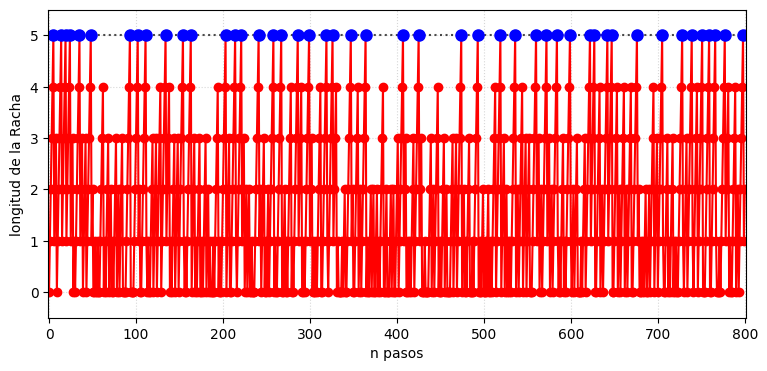

Tiempos Medios de transición:
Desde 0 hasta 0 (u_00): 0.00 pasos.
Desde 0 hasta 1 (u_01): 1.43 pasos.
Desde 0 hasta 2 (u_02): 3.47 pasos.
Desde 0 hasta 3 (u_03): 6.38 pasos.
Desde 0 hasta 4 (u_04): 10.55 pasos.
Desde 0 hasta 5 (u_05): 16.50 pasos.
Desde 1 hasta 0 (u_10): 1.00 pasos.
Desde 1 hasta 1 (u_11): 1.43 pasos.
Desde 1 hasta 2 (u_12): 2.04 pasos.
Desde 1 hasta 3 (u_13): 4.96 pasos.
Desde 1 hasta 4 (u_14): 9.12 pasos.
Desde 1 hasta 5 (u_15): 15.07 pasos.
Desde 2 hasta 0 (u_20): 1.70 pasos.
Desde 2 hasta 1 (u_21): 1.43 pasos.
Desde 2 hasta 2 (u_22): 3.47 pasos.
Desde 2 hasta 3 (u_23): 2.92 pasos.
Desde 2 hasta 4 (u_24): 7.08 pasos.
Desde 2 hasta 5 (u_25): 13.03 pasos.
Desde 3 hasta 0 (u_30): 2.19 pasos.
Desde 3 hasta 1 (u_31): 1.43 pasos.
Desde 3 hasta 2 (u_32): 3.47 pasos.
Desde 3 hasta 3 (u_33): 6.38 pasos.
Desde 3 hasta 4 (u_34): 4.16 pasos.
Desde 3 hasta 5 (u_35): 10.11 pasos.
Desde 4 hasta 0 (u_40): 2.53 pasos.
Desde 4 hasta 1 (u_41): 1.43 pasos.
Desde 4 hasta 2 (u_42): 3.47 

In [10]:
pasos_totales_infinito = 800 # Número de pasos 
racha_actual = 0
historial_rachas_infinito = [0]
historial_letras_infinito = []

# Distribución estacionaria
A = matriz_P.T - np.eye(N + 1)
A[-1, :] = 1.0
b = np.zeros(N + 1)
b[-1] = 1.0
pi_valores = np.linalg.solve(A, b)

# Tiempos Medios de Transición u_ij para el caso infinito
M_transicion_inf = np.zeros((N + 1, N + 1))
for i in range(N + 1):
    for j in range(N + 1):
        if i < j:
            M_transicion_inf[i, j] = sum([1 / (p**k) for k in range(i + 1, j + 1)])
        else:
            if j == 0:
                M_transicion_inf[i, j] = (1 / (1 - p)) * (1 - p**i)
            else:
                M_transicion_inf[i, j] = sum([1 / (p**k) for k in range(1, j + 1)])

# Bucle continuo
for _ in range(pasos_totales_infinito):
    val = random.random()
    if val < p:
        historial_letras_infinito.append('p')
        if racha_actual == N:
            racha_actual = 1
        else:
            racha_actual += 1
    else:
        historial_letras_infinito.append('q')
        racha_actual = 0 
        
    historial_rachas_infinito.append(racha_actual)
instantes_exito = [i for i, x in enumerate(historial_rachas_infinito) if x == N]

# Gráfica
plt.figure(figsize=(9, 4), dpi=100)
plt.plot(historial_rachas_infinito, color="red", marker="o", linestyle="-")
plt.axhline(y=N, color="black", linestyle=":", alpha=0.7)
plt.plot(instantes_exito, [N] * len(instantes_exito), 'bo', markersize=8)

plt.xlim(-1, pasos_totales_infinito + 1)
plt.ylim(-0.5, N + 0.5)
plt.ylabel("longitud de la Racha")
plt.xlabel("n pasos")
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

# Visualización de resultados
print("Tiempos Medios de transición:")
for i in range(N + 1):
    for j in range(N + 1):
        print(f"Desde {i} hasta {j} (u_{i}{j}): {M_transicion_inf[i, j]:.2f} pasos.")
print()

# Tiempos Medios de Recurrencia: mu_ii = 1 / pi_i
mu_valores = np.zeros(N + 1)

print("Tiempos Medios de Recurrencia:")
for estado in range(N + 1):
    mu_valores[estado] = 1 / pi_valores[estado]
    print(f"Tiempo medio de recurrencia desde Estado {estado} (u_{estado}{estado}): {mu_valores[estado]:.2f} pasos.")
print()

print("Distribución Estacionaria:")
for estado in range(N + 1):
    print(f"Probabilidad estacionaria del Estado {estado} (pi_{estado}): {pi_valores[estado]:.4f}")
print()

print(f"Pasos donde se completó la racha en la simulación infinita: {instantes_exito}\n")

# Análsiis de la simulación frente a los datos esperados
print("Distancias entre Éxitos consecutivos:")
if len(instantes_exito) > 1:
    distancias_reales = [b - a for a, b in zip(instantes_exito, instantes_exito[1:])]
    cadena_suma = " + ".join([str(d) for d in distancias_reales])
    promedio_empirico = sum(distancias_reales) / len(distancias_reales)
    
    # Mostrar la comparación
    print(f"promedio: ({cadena_suma}) / {len(distancias_reales)}")
    print()
    print(f"Promedio de pasos de regreso (Simulación): {promedio_empirico:.2f} pasos.")
    print(f"Tiempo medio de recurrencia esperado (Teoría mu_{N}{N}): {mu_valores[N]:.2f} pasos.")
else:
    print("No se registraron suficientes éxitos en esta simulación para calcular distancias.")

Pasos para alcanzar la racha: 15 pasos.


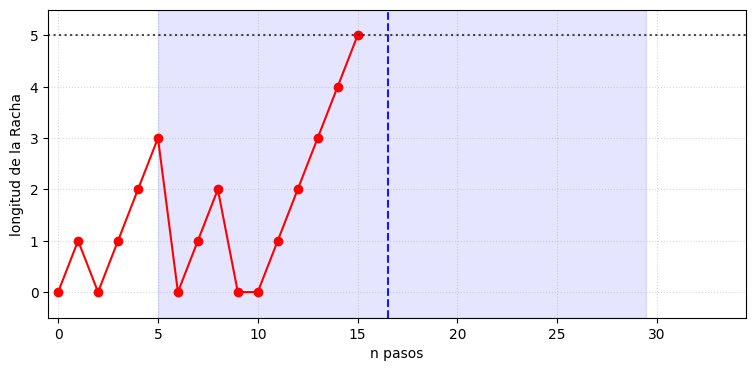

Tiempos Medios de transición:
Desde el Estado 0 hasta el Estado 0 (u_00): 0.00 pasos.
Desde el Estado 0 hasta el Estado 1 (u_01): 1.43 pasos.
Desde el Estado 0 hasta el Estado 2 (u_02): 3.47 pasos.
Desde el Estado 0 hasta el Estado 3 (u_03): 6.38 pasos.
Desde el Estado 0 hasta el Estado 4 (u_04): 10.55 pasos.
Desde el Estado 0 hasta el Estado 5 (u_05): 16.50 pasos.
Desde el Estado 1 hasta el Estado 0 (u_10): 1.00 pasos.
Desde el Estado 1 hasta el Estado 1 (u_11): 0.00 pasos.
Desde el Estado 1 hasta el Estado 2 (u_12): 2.04 pasos.
Desde el Estado 1 hasta el Estado 3 (u_13): 4.96 pasos.
Desde el Estado 1 hasta el Estado 4 (u_14): 9.12 pasos.
Desde el Estado 1 hasta el Estado 5 (u_15): 15.07 pasos.
Desde el Estado 2 hasta el Estado 0 (u_20): 1.70 pasos.
Desde el Estado 2 hasta el Estado 1 (u_21): 1.43 pasos.
Desde el Estado 2 hasta el Estado 2 (u_22): 0.00 pasos.
Desde el Estado 2 hasta el Estado 3 (u_23): 2.92 pasos.
Desde el Estado 2 hasta el Estado 4 (u_24): 7.08 pasos.
Desde el Estado

In [13]:
# Construcción de la matriz de transición de estados transitorios Q
Q = np.zeros((N, N))
for i in range(N):
    Q[i, 0] = 1 - p  
    if i + 1 < N:
        Q[i, i + 1] = p 

# Matriz Fundamental: M = (I - Q)^-1
I = np.eye(N)
M_fundamental = np.linalg.inv(I - Q)

# Tiempos medios de absorción
tiempos_absorcion = np.sum(M_fundamental, axis=1)
tiempo_esperado_m0 = tiempos_absorcion[0]
visualizar_formula = " + ".join([f"(1/{p}^{k})" for k in range(1, N + 1)])

# Matriz completa de tiempos de transición
M_transicion = np.zeros((N + 1, N + 1))

# Tiempos de transición u_ij 
for i in range(N + 1):
    for j in range(N + 1):
        if i == j:
            M_transicion[i, j] = 0.0
        elif j == N:
            # Si el destino es el absorbente N, se usan lo calculado para tiempos de absorción
            M_transicion[i, j] = tiempos_absorcion[i] if i < N else 0.0
        elif i == N:
            # El estado N es absorbente
            M_transicion[i, j] = 0.0
        else:
            # Caminos de transición posibles entre estados transitorios 
            if i < j:
                # Tiempo para avanzar de un estado menor a uno mayor
                M_transicion[i, j] = sum([1 / (p**k) for k in range(i + 1, j + 1)])
            else:
                # Tiempo para retroceder hacia un estado menor
                M_transicion[i, j] = sum([1 / (p**k) for k in range(1, j + 1)]) if j > 0 else (1 / (1 - p)) * (1 - p**i)

# Varianza
numerador_var = 1 - (2 * N + 1) * (1 - p) * (p**N) - (p**(2 * N + 1))
denominador_var = (p**(2 * N)) * ((1 - p)**2)
varianza_teorica = numerador_var / denominador_var
desviacion_teorica = np.sqrt(varianza_teorica)

cota_inferior = max(N, tiempo_esperado_m0 - desviacion_teorica)
cota_superior = tiempo_esperado_m0 + desviacion_teorica

# Gráfica
racha_actual = 0
historial_rachas_estatico = [0]
historial_letras_estatico = []
pasos_dados = 0
# Simulación rápida para el caso absorbente
while racha_actual < N:
    pasos_dados += 1
    val = random.random()
    if val < p:
        historial_letras_estatico.append('p') 
        racha_actual += 1
    else:
        historial_letras_estatico.append('q') 
        racha_actual = 0
    historial_rachas_estatico.append(racha_actual)

print(f"Pasos para alcanzar la racha: {pasos_dados} pasos.")

plt.figure(figsize=(9, 4), dpi=100)
plt.plot(historial_rachas_estatico, color="red", marker="o", linestyle="-")
plt.axhline(y=N, color="black", linestyle=":", alpha=0.7)
plt.axvline(x=tiempo_esperado_m0, color="blue", linestyle="--", alpha=0.9)
plt.axvspan(cota_inferior, cota_superior, color='blue', alpha=0.1)

limite_derecho_x = max(tiempo_esperado_m0 + desviacion_teorica + 5, pasos_dados + 2)
plt.xlim(-0.5, limite_derecho_x)
plt.ylim(-0.5, N + 0.5)

plt.ylabel("longitud de la Racha")
plt.xlabel("n pasos")
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

# Visualización de resultados
print("Tiempos Medios de transición:")
for i in range(N + 1):
    for j in range(N + 1):
        if i == N and j < N:
            continue
        print(f"Desde el Estado {i} hasta el Estado {j} (u_{i}{j}): {M_transicion[i, j]:.2f} pasos.")
print()

print("Tiempos Medios de Absorción:")
for estado_origen, tiempo_viaje in enumerate(tiempos_absorcion):
    print(f"Desde el Estado {estado_origen} hasta el Absorbente {N} (u_{estado_origen}{N}): {tiempo_viaje:.2f} pasos.")
print()

print(f"m_0 = {visualizar_formula}")
print(f"Tiempo medio esperado (m_0): {tiempo_esperado_m0:.2f} pasos.\n")

print(f"Desviación Estándar: {desviacion_teorica:.2f} pasos.")
print(f"Cotas de dispersión estándar: [{cota_inferior:.2f} a {cota_superior:.2f}] pasos.\n")